In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')


df = pd.read_csv(r'C:\Users\emree\OneDrive\Masaüstü\veri\Heart_Disease_Prediction.csv')


print(df.columns)
display(df.head())

Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease'],
      dtype='object')


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


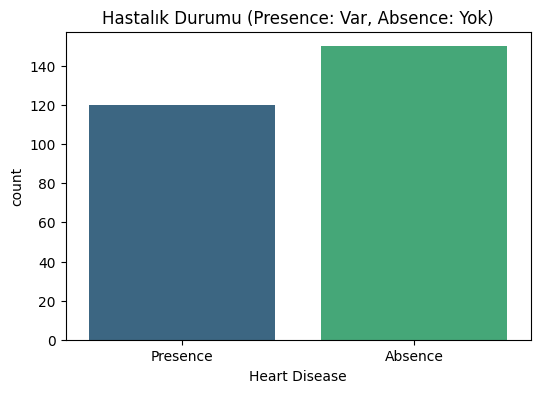

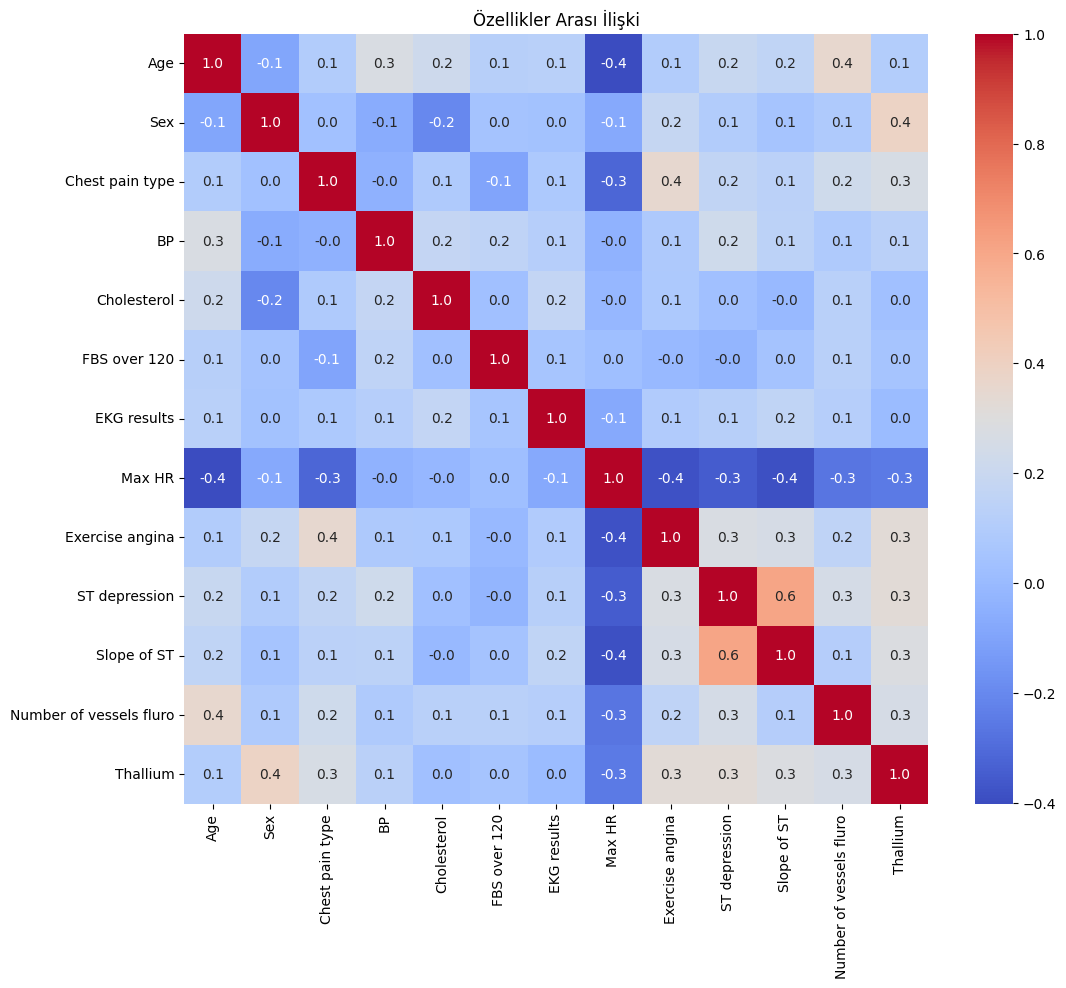

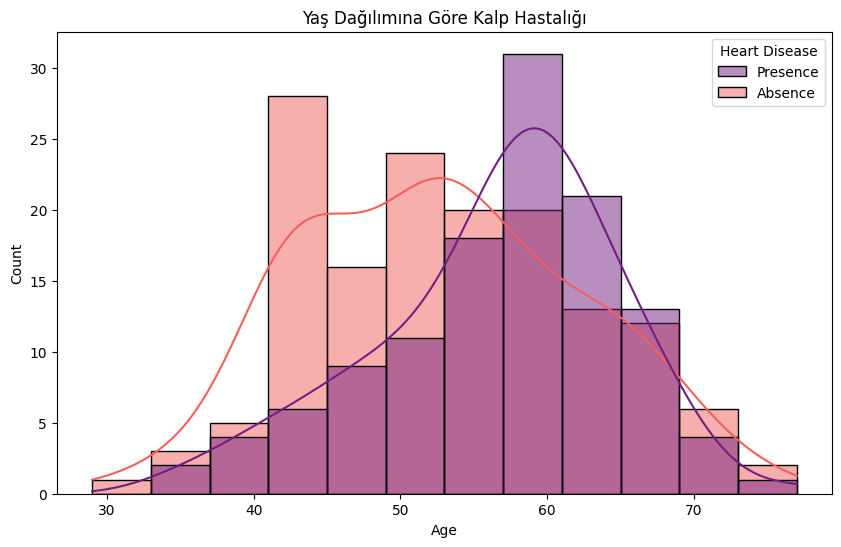

In [ ]:



plt.figure(figsize=(6, 4))
sns.countplot(x='Heart Disease', data=df, palette='viridis')
plt.title('Hastalık Durumu (Presence: Var, Absence: Yok)')
plt.savefig('hasta_dagilimi.png') 
plt.show()



numeric_df = df.select_dtypes(include=[np.number]) 
plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".1f", cmap='coolwarm')
plt.title('Özellikler Arası İlişki')
plt.savefig('korelasyon.png')
plt.show()


plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', hue='Heart Disease', kde=True, palette='magma')
plt.title('Yaş Dağılımına Göre Kalp Hastalığı')
plt.show()

In [ ]:



df['Heart Disease'] = df['Heart Disease'].map({'Presence': 1, 'Absence': 0})

print("Dönüştürme tamamlandı! İşte son durum:")
display(df.head())


X = df.drop('Heart Disease', axis=1) # Son sütunu at, gerisi soru
y = df['Heart Disease']              # Sadece son sütun cevap


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nVeriler eğitime hazır!")

Dönüştürme tamamlandı! İşte son durum:


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0



Veriler eğitime hazır!


Lojistik Regresyon Başarısı: %90.74
Random Forest Başarısı:      %75.93

Random Forest Detaylı Raporu:
              precision    recall  f1-score   support

           0       0.78      0.85      0.81        33
           1       0.72      0.62      0.67        21

    accuracy                           0.76        54
   macro avg       0.75      0.73      0.74        54
weighted avg       0.76      0.76      0.76        54



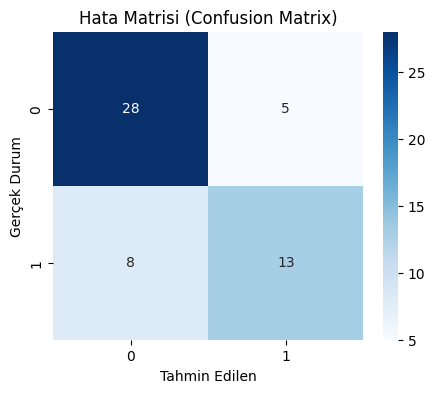

In [ ]:



log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)
acc_log = accuracy_score(y_test, y_pred_log)


rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"Lojistik Regresyon Başarısı: %{acc_log * 100:.2f}")
print(f"Random Forest Başarısı:      %{acc_rf * 100:.2f}")

print("\nRandom Forest Detaylı Raporu:")
print(classification_report(y_test, y_pred_rf))


plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title('Hata Matrisi (Confusion Matrix)')
plt.ylabel('Gerçek Durum')
plt.xlabel('Tahmin Edilen')
plt.show()